In [10]:
import numpy as np
import math
import cmath

import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *

import numpy as np 
import matplotlib.pyplot as plt
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
from scipy.integrate import simpson, quad
import copy as cp

In [11]:
# Gaussian fit
def gaus(data, amplitude, mean, sigma):
    return amplitude * math.e**((-0.5 * (data - mean)**2) / sigma**2)

def fluctuated_fit(gaus, bin_centers, counts):
    popt, _ = curve_fit(gaus, bin_centers, counts)
    return popt

def hamiltonian_4nu_coefficients():
    return

def evolution_operator_4nu_u_coefficients():
    return

def evolution_operator_4nu():
    return

In [12]:
# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

adjusted_counts_fd = np.array([ 0.  ,  7.5 ,  1.  ,  3.  ,  1.  ,  2.  ,  2.  ,  4.  ,  6.  ,
        9.  , 15.  , 12.  , 39.5 , 25.  , 19.25, 20.25, 16.  , 14.  ,
       18.  ])
adjusted_counts_nd = np.array([ 37500., 105000.,  72000.,  96000., 120000., 148000., 170000.,
       192000., 208000., 214000., 212000., 204000., 425000., 280000.,
       181500.,  81000.,  80000.,  25000.,  10000.])

counts_nd_e = np.array([0.4, 2, 3.8, 5.75, 3.4, 1.8, 1 ,0.9, 0.75])
bin_edges_e = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])

length_nd = 1 # [km]
length_fd = 810 # [km]

# Finding the Gaussian fit for the observed energy spectrum

initial_guess = [140, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")

popt_fd, _ =curve_fit(gaus, bin_centers, counts_fd)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")
energy = np.linspace(0.01, 5.0, 400)


Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692699546734, Mean = 1.8044188236655974, Sigma = 0.5254484171717854
Fitted parameters for observed the unoscillated ND events: Amplitude = 13.876682332452186, Mean = 2.2114226340866225, Sigma = -0.49524730606517153


In [13]:
def mixing_matrix_4nu(alpha):
# Returns the mixing matrix for a given alpha
# alpha can be [np.pi / 4, np.pi / 6, np.pi / 3]

    c12 = 0.83
    s12 = 0.56
    s23 = c23 = 0.7071
    s13 = 0.15
    c13 = 0.15


    c_alpha = np.cos(alpha)
    s_alpha = np.sin(alpha)
    dCP = 217./180.*np.pi
    cdCP = np.cos(dCP)
    sdCP = np.sin(dCP)

    A = -(c23*s12 + c12*s13*s23*complex(cdCP,sdCP))
    B = c23*c12 - s12*s13*s23*complex(cdCP,sdCP)
    C = s23*s12 - c12*s13*s23*complex(cdCP,sdCP)
    D = -(s23*c12 + s12*s13*c23*complex(cdCP,sdCP))

    U00 = c12*c13*c_alpha
    U01 = c13*(s12*c_alpha - c12*s_alpha**2)
    U02 = -c13*s_alpha**2 * (c12*c_alpha + s12) + s13*c_alpha
    U03 = c13*s_alpha*c_alpha*(c12*c_alpha + s12) +s12*s_alpha

    U10 = A*c_alpha
    U11 = -A*s_alpha**2 + B*c_alpha
    U12 = -A*s_alpha**2*c_alpha - B*s_alpha**2 + c13*s23* complex(cdCP,sdCP) *c_alpha
    U13 = A * s_alpha*c_alpha**2 + B*s_alpha*c_alpha + c13*s23 * complex(cdCP,sdCP)

    U20 = C*c_alpha
    U21 = -C*s_alpha**2 + D*c_alpha
    U22 = -C*s_alpha**2 * c_alpha - D*s_alpha**2 + c13*c23*complex(cdCP,sdCP)
    U23 = C*s_alpha*c_alpha**2 + D*s_alpha*c_alpha + c13*s23*complex(cdCP,sdCP)
    
    U30 = -s_alpha
    U31 = -s_alpha*c_alpha
    U32 = -s_alpha*c_alpha**2
    U33 = c_alpha**3

    return [[U00, U01, U02, U03], [U10, U11, U12, U13], [U20, U21, U22, U23], [U30, U31, U32, U33]]

def hamiltonian_4nu(alpha, Dm14):
# returns the hamltonian for a given alpha and Dm14 (delta mass squared j4, (j=1,2,3 but all Dmj4 have the same value))
# Dm14 = [0.9, 0.043] eV      
    Dm12 = 7.6e-5
    Dm13 = 2.4e-3 
    f = 1/2

    M2 = np.array([[0,0,0,0],[0,Dm12,0,0],[0,0,Dm13,0],[0,0,0,Dm14]]) # guessed mass matrix, using info for the 2x2 and 3x3 matrices
    R = np.array(mixing_matrix_4nu(alpha))
    #print('Mixing matrix', R)
    H = list(f*np.matmul(R, np.matmul(M2, np.conj(matrix.transpose(R)))))

    return H

def hamiltonian_4nu_matter(hamiltonian, energy, density):
    return

def probabilities_4nu(length, alpha, Dm14 ,e):
    # calculates osc prob 
    # Prob nu_mu --> nu_e 
        # got it from https://arxiv.org/pdf/1601.05391
    E = e * 1e9
    delta_L = (7.6e-5 / 2*E) * length
    Delta_L = (2.4e-3 / 2*E) * length
    gamma_L = (Dm14 / 2*E) * length

    c_alpha = np.cos(alpha)
    s_alpha = np.sin(alpha)

    U00 = 0.822*c_alpha
    U01 = -0.554*s_alpha**2 + 0.084*c_alpha
    U02 = -0.822*s_alpha**2 *c_alpha - 0.554*s_alpha**2 + 0.15*c_alpha
    U03 = 0.822*s_alpha*c_alpha**2 + 0.554*s_alpha*c_alpha + 0.15*s_alpha
    U10 = -0.484*c_alpha
    U11 = 0.484*s_alpha**2 + 0.527*c_alpha
    U12 = 0.484*c_alpha - 0.527*s_alpha**2 + 0.7*c_alpha
    U13 = -0.484*s_alpha*c_alpha**2 + 0.527*s_alpha*c_alpha +0.7*s_alpha

    probability = (
        U00**2 * U10**2 + U01**2 * U11**2 + U02**2 * U12**2 +
        U03**2 * U13**2 +2*U00*U10*U01*U11*np.cos(delta_L) +
        2*(U00*U10*U02*U11 + U01*U11*U02*U12)*np.cos(Delta_L) +
        2*U03*U13*(U00*U10 + U01*U11 + U02*U12)*np.cos(gamma_L)
    )

    return probability

def osc_prob_4nu(length, alpha, Dm14):

    popt = popt_nd
    probabilities = []

    h_vacuum = hamiltonian_4nu(alpha,Dm14)
    length_scaled = length * CONV_KM_TO_INV_EV
        
    probabilities = [probabilities_4nu(length, alpha, Dm14, e) for e in energy]

    gaus_fit = probabilities * gaus(energy, *popt)

    return probabilities, gaus_fit

Probability  [0.75324808509511, 0.8289696608924153, 0.766668445170642, 0.30058134583141116, 0.04969535747689041, -0.1546627991428094, -0.06451585246424246, 0.13529024370154247, 0.279285997868676, 0.5067656787688886, 0.5019730886612658, 0.6417470123596841, 0.4863592895881977, 0.3751036213134973, 0.055006841876655, -0.17388969520628195, -0.17380821077843747, 0.007542805514829921, 0.5224045763143785, 0.7816954236135703, 0.9515091395527528, 0.5722462654431997, 0.14660959672661256, -0.27306109670726997, -0.3520034693122268, -0.025158730110819316, 0.3357601955475604, 0.7703549965517956, 0.7342172003753212, 0.6462384486874406, 0.27861079252886173, 0.09118792394023276, -0.01961006964524553, -0.03137975154274486, 0.11716469157080472, 0.16069254627259635, 0.4390473622275759, 0.5249219923258347, 0.7287424618854896, 0.5988286866993744, 0.3547946901181307, -0.010015303605288906, -0.311239063729339, -0.1927111976742237, 0.06675466378519074, 0.649517827668372, 0.8652252393636393, 0.900487372955537, 0

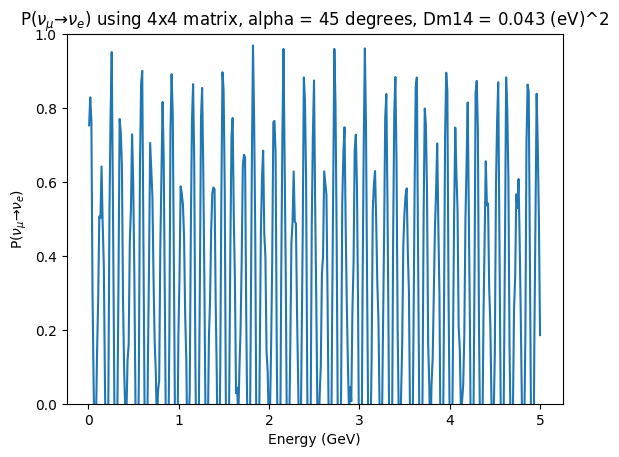

In [14]:
prob, gaus_ = osc_prob_4nu(length_fd, np.pi/4, 0.043)
print('Probability ',prob)
plt.figure()


print(energy_nu)
plt.plot(energy, prob)
plt.xlabel('Energy (GeV)')
plt.ylabel(r'P($\nu_\mu \to \nu_e$)')
#plt.xlim([10.**log10_energy_nu_min, 10.**log10_energy_nu_max])
#plt.xscale('log')
plt.ylim([0,1])
plt.title(r'P($\nu_\mu \to \nu_e$) using 4x4 matrix, alpha = 45 degrees, Dm14 = 0.043 (eV)^2')
plt.show()


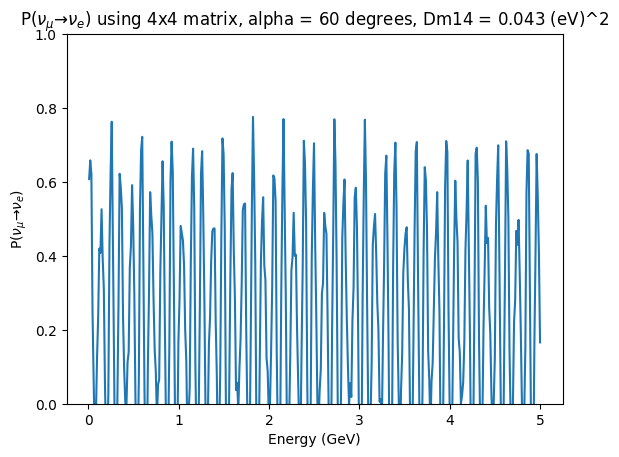

In [15]:
prob2, gaus_2 = osc_prob_4nu(length_fd, np.pi/3, 0.043)

plt.figure()
plt.plot(energy, prob2)
plt.xlabel('Energy (GeV)')
plt.ylabel(r'P($\nu_\mu \to \nu_e$)')
#plt.xlim([10.**log10_energy_nu_min, 10.**log10_energy_nu_max])
#plt.xscale('log')
plt.ylim([0,1])

plt.title(r'P($\nu_\mu \to \nu_e$) using 4x4 matrix, alpha = 60 degrees, Dm14 = 0.043 (eV)^2')
plt.show()

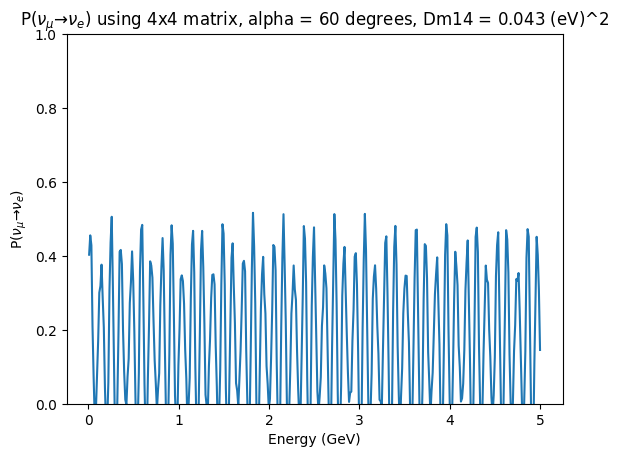

In [16]:
prob3, gaus_3 = osc_prob_4nu(length_fd, np.pi/6, 0.043)

plt.figure()
plt.plot(energy, prob3)
plt.xlabel('Energy (GeV)')
plt.ylabel(r'P($\nu_\mu \to \nu_e$)')
#plt.xlim([10.**log10_energy_nu_min, 10.**log10_energy_nu_max])
#plt.xscale('log')
plt.ylim([0,1])

plt.title(r'P($\nu_\mu \to \nu_e$) using 4x4 matrix, alpha = 60 degrees, Dm14 = 0.043 (eV)^2')
plt.show()

In [17]:
print('Probability 1',prob)
print('Probability 2',prob2)
print('Probability 3',prob3)


Probability 1 [0.75324808509511, 0.8289696608924153, 0.766668445170642, 0.30058134583141116, 0.04969535747689041, -0.1546627991428094, -0.06451585246424246, 0.13529024370154247, 0.279285997868676, 0.5067656787688886, 0.5019730886612658, 0.6417470123596841, 0.4863592895881977, 0.3751036213134973, 0.055006841876655, -0.17388969520628195, -0.17380821077843747, 0.007542805514829921, 0.5224045763143785, 0.7816954236135703, 0.9515091395527528, 0.5722462654431997, 0.14660959672661256, -0.27306109670726997, -0.3520034693122268, -0.025158730110819316, 0.3357601955475604, 0.7703549965517956, 0.7342172003753212, 0.6462384486874406, 0.27861079252886173, 0.09118792394023276, -0.01961006964524553, -0.03137975154274486, 0.11716469157080472, 0.16069254627259635, 0.4390473622275759, 0.5249219923258347, 0.7287424618854896, 0.5988286866993744, 0.3547946901181307, -0.010015303605288906, -0.311239063729339, -0.1927111976742237, 0.06675466378519074, 0.649517827668372, 0.8652252393636393, 0.900487372955537, 

Probability 1 [0.9291480182928664, 0.7679548674634747, 0.6695081172994397, 0.36332548344204896, 0.36769482108499496, 0.3651737873777904, 0.4774634046518885, 0.475994269673978, 0.2555386399756101, 0.09224940865575693, -0.17942905025565914, -0.08865364008515852, -0.0806180397658276, 0.0823499205947143, -0.002119598179775972, -0.16058978190453477, -0.29924940506990394, -0.4062332711298702, -0.19398223508428658, -0.1039712785186962, 0.12039164265852803, 0.010168990373790154, -0.03717171895854887, -0.12165104979282454, -0.037133653128166494, 0.23601427678745915, 0.38435876034909444, 0.5813056418811408, 0.4280463271081332, 0.4316852375298943, 0.3530200530859908, 0.5453068984511464, 0.7524781133371663, 0.8693438492322836, 0.9137509058594553, 0.6810222907951957, 0.6469890992911593, 0.5316874374322494, 0.7351384765298337, 0.7956155551575395, 0.8280056740235804, 0.6758326942523135, 0.3992430549663727, 0.3148844913774478, 0.20816908929428304, 0.40039413600110924, 0.3503833078749608, 0.33511217868

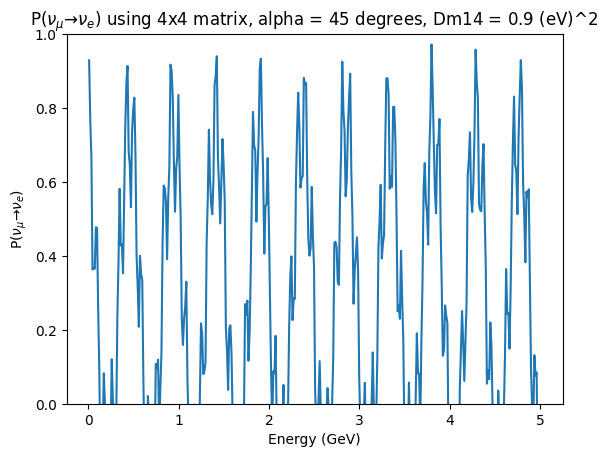

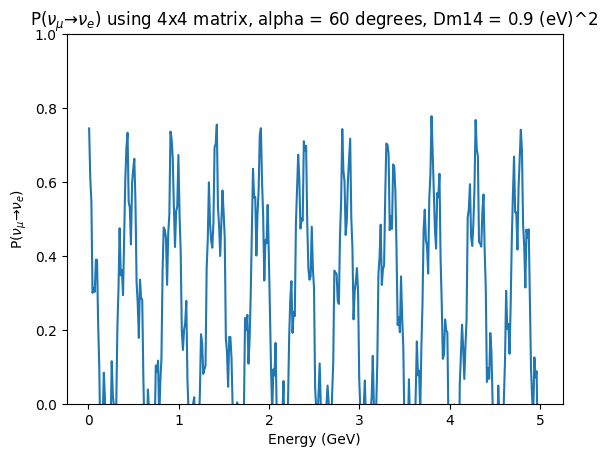

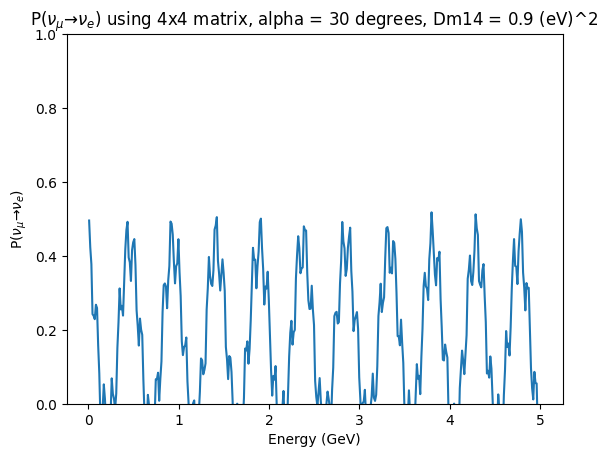

In [18]:
prob_1, gaus_4 = osc_prob_4nu(length_fd, np.pi/4, 0.9)
prob_2, gaus_5 = osc_prob_4nu(length_fd, np.pi/3, 0.9)
prob_3, gaus_6 = osc_prob_4nu(length_fd, np.pi/6, 0.9)

print('Probability 1',prob_1)
print('Probability 2',prob_2)
print('Probability 3',prob_3)

plt.figure()
plt.plot(energy, prob_1)
plt.xlabel('Energy (GeV)')
plt.ylabel(r'P($\nu_\mu \to \nu_e$)')
#plt.xlim([10.**log10_energy_nu_min, 10.**log10_energy_nu_max])
#plt.xscale('log')
plt.ylim([0,1])

plt.title(r'P($\nu_\mu \to \nu_e$) using 4x4 matrix, alpha = 45 degrees, Dm14 = 0.9 (eV)^2')
plt.show()

plt.figure()
plt.plot(energy, prob_2)
plt.xlabel('Energy (GeV)')
plt.ylabel(r'P($\nu_\mu \to \nu_e$)')
plt.ylim([0,1])

#plt.xlim([10.**log10_energy_nu_min, 10.**log10_energy_nu_max])
#plt.xscale('log')
plt.title(r'P($\nu_\mu \to \nu_e$) using 4x4 matrix, alpha = 60 degrees, Dm14 = 0.9 (eV)^2')
plt.show()

plt.figure()
plt.plot(energy, prob_3)
plt.xlabel('Energy (GeV)')
plt.ylabel(r'P($\nu_\mu \to \nu_e$)')
plt.ylim([0,1])

#plt.xlim([10.**log10_energy_nu_min, 10.**log10_energy_nu_max])
#plt.xscale('log')
plt.title(r'P($\nu_\mu \to \nu_e$) using 4x4 matrix, alpha = 30 degrees, Dm14 = 0.9 (eV)^2')
plt.show()